<a href="https://colab.research.google.com/github/BhavyaGoyal28/ShapeAI_BWD/blob/main/Creditcards.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from google.colab import files

In [15]:
uploaded = files.upload()  # Colab will prompt you to upload 'creditcard.csv'
for filename in uploaded.keys():
    df = pd.read_csv(filename)

Saving creditcard.csv.zip to creditcard.csv (1).zip


In [16]:
print("Data Loaded Successfully!")
print(df.info())
print(df.describe())

Data Loaded Successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-nul

In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric Columns: {numeric_cols[:10]} ...")


Numeric Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9'] ...


In [18]:
df = df.dropna()

In [19]:
target_col = 'Amount' if 'Amount' in df.columns else numeric_cols[-1]
predictors = [col for col in numeric_cols if col != target_col][:3]  # Use first 3 predictors
print(f"\nTarget Variable: {target_col}")
print(f"Predictors Used: {predictors}")


Target Variable: Amount
Predictors Used: ['Time', 'V1', 'V2']


In [20]:
X = sm.add_constant(df[predictors[0]])
y = df[target_col]
model = sm.OLS(y, X).fit()

In [21]:
print("\n--- SIMPLE LINEAR REGRESSION SUMMARY ---")
print(model.summary())


--- SIMPLE LINEAR REGRESSION SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:                 Amount   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     31.98
Date:                Sat, 11 Oct 2025   Prob (F-statistic):           1.56e-08
Time:                        04:04:40   Log-Likelihood:            -1.9768e+06
No. Observations:              284807   AIC:                         3.954e+06
Df Residuals:                  284805   BIC:                         3.954e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

In [22]:
residuals = model.resid
fitted = model.fittedvalues

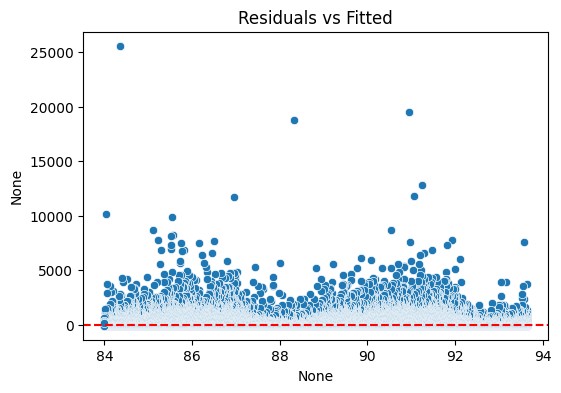

In [23]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted')
plt.show()

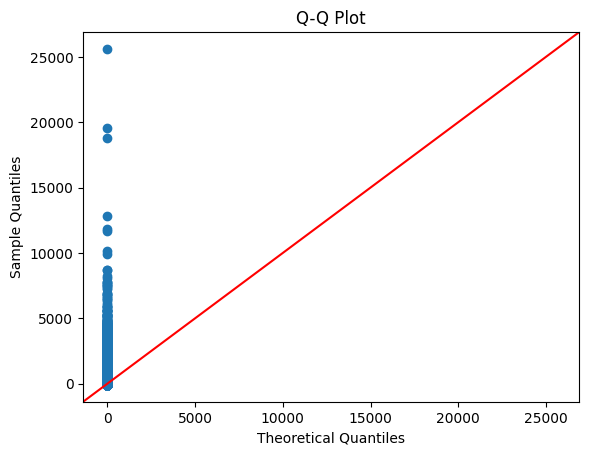

In [24]:
sm.qqplot(residuals, line='45')
plt.title('Q-Q Plot')
plt.show()

In [25]:
X_multi = sm.add_constant(df[predictors])
multi_model = sm.OLS(y, X_multi).fit()

print("\n--- MULTIPLE REGRESSION SUMMARY ---")
print(multi_model.summary())


--- MULTIPLE REGRESSION SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:                 Amount   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                 4.769e+04
Date:                Sat, 11 Oct 2025   Prob (F-statistic):               0.00
Time:                        04:05:49   Log-Likelihood:            -1.9189e+06
No. Observations:              284807   AIC:                         3.838e+06
Df Residuals:                  284803   BIC:                         3.838e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         8

In [26]:
anova_results = sm.stats.anova_lm(model, multi_model)
print("\n--- MODEL COMPARISON (ANOVA) ---")
print(anova_results)


--- MODEL COMPARISON (ANOVA) ---
   df_resid           ssr  df_diff       ss_diff             F  Pr(>F)
0  284805.0  1.781548e+10      0.0           NaN           NaN     NaN
1  284803.0  1.186005e+10      2.0  5.955429e+09  71505.743968     0.0


In [27]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X_multi.columns
vif_data["VIF"] = [variance_inflation_factor(X_multi.values, i) for i in range(X_multi.shape[1])]
print("\n--- VARIANCE INFLATION FACTOR (VIF) ---")
print(vif_data)


--- VARIANCE INFLATION FACTOR (VIF) ---
  Feature       VIF
0   const  5.042511
1    Time  1.014090
2      V1  1.013976
3      V2  1.000114


In [28]:
robust_model = sm.RLM(y, X_multi, M=sm.robust.norms.HuberT()).fit()
print("\n--- ROBUST REGRESSION SUMMARY ---")
print(robust_model.summary())



--- ROBUST REGRESSION SUMMARY ---
                    Robust linear Model Regression Results                    
Dep. Variable:                 Amount   No. Observations:               284807
Model:                            RLM   Df Residuals:                   284803
Method:                          IRLS   Df Model:                            3
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sat, 11 Oct 2025                                         
Time:                        04:06:40                                         
No. Iterations:                    45                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.

In [29]:
new_data = pd.DataFrame({predictors[0]: [-1, 0, 1]})
new_data = sm.add_constant(new_data)
predictions = model.get_prediction(new_data).summary_frame(alpha=0.05)
print("\n--- PREDICTIONS (WITH CONFIDENCE INTERVALS) ---")
print(predictions)


--- PREDICTIONS (WITH CONFIDENCE INTERVALS) ---
        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  93.641342  1.046513      91.590206      95.692477   -396.564776   
1  93.641286  1.046504      91.590168      95.692404   -396.564832   
2  93.641230  1.046495      91.590129      95.692331   -396.564888   

   obs_ci_upper  
0    583.847460  
1    583.847404  
2    583.847348  


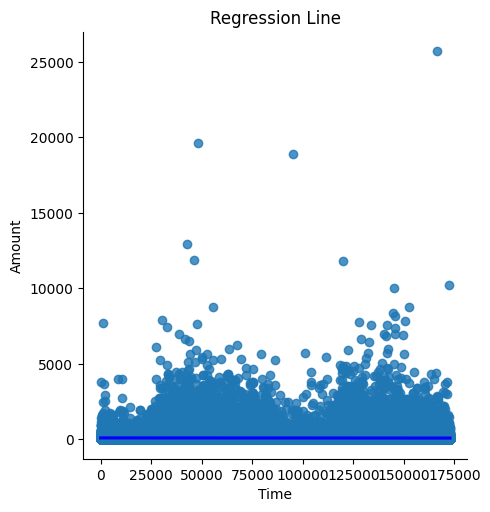

In [30]:
sns.lmplot(x=predictors[0], y=target_col, data=df, line_kws={'color': 'blue'})
plt.title('Regression Line')
plt.show()